# 06 · Multivariate diagnostics, PERMANOVA and dispersion

Diagnose the geometry of a numerical space and then ask whether predefined groups differ in multivariate location and/or dispersion.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_multivariate, analyze_permutation_group_structure, analyze_pca
frame,dataset=load_tabular_demo(); features=load_feature_demo('representation_a')
mv=analyze_multivariate(features,scaling='standard',random_state=42)
perm=analyze_permutation_group_structure(features,dataset,factor='group',metric='euclidean',n_permutations=39,random_state=42)
pca=analyze_pca(features,n_components=3,scaling='standard')

## Covariance/correlation structure

findfont: Failed to find font weight semibold, now using 700.


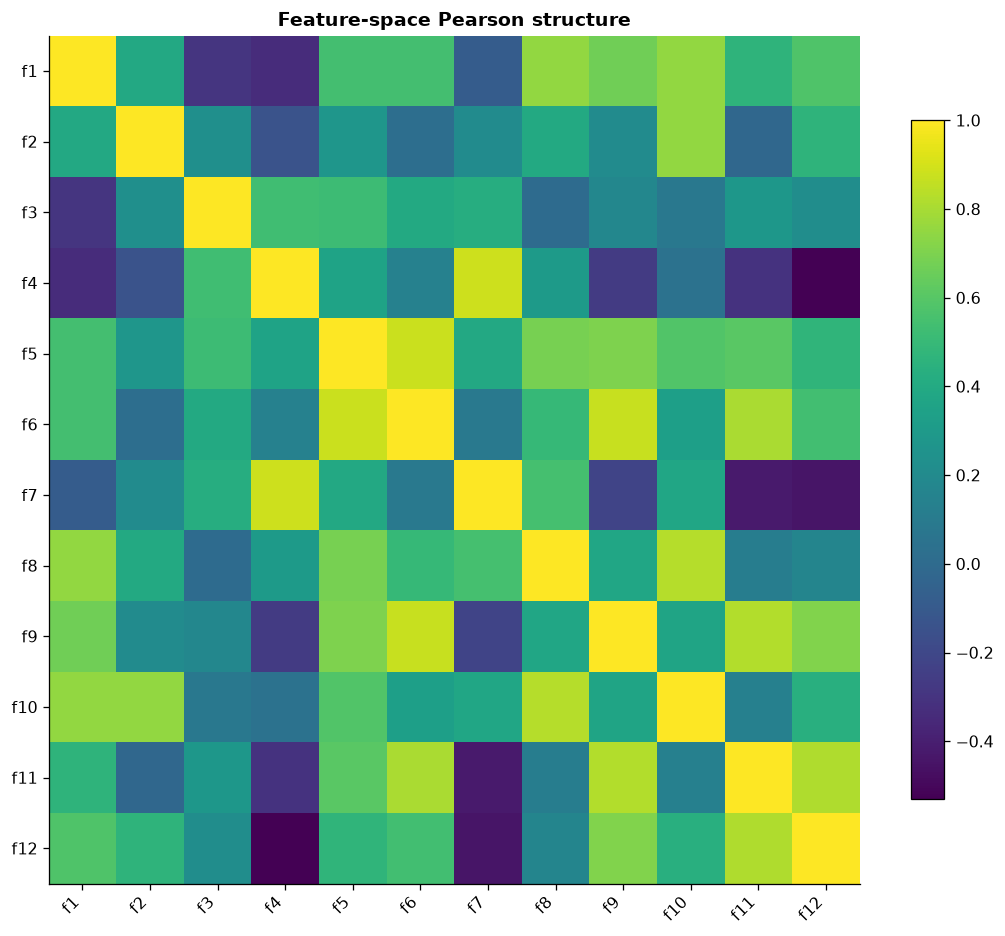

In [2]:
matrix_heatmap(mv.covariance.pearson,title='Feature-space Pearson structure',annotate=False); plt.show()

## Collinearity diagnostics

In [3]:
vif=mv.collinearity.features.query('status=="ok"').copy() if hasattr(mv.collinearity,'features') else mv.collinearity.table.query('status=="ok"').copy(); display(vif.head())

,feature,vif,tolerance,is_constant,status,reason
0,f1,40.196805,0.024878,False,ok,None
1,f2,11.862067,0.084302,False,ok,None
2,f3,14.027714,0.071287,False,ok,None
3,f4,26.946096,0.037111,False,ok,None
4,f5,18.950748,0.052768,False,ok,None


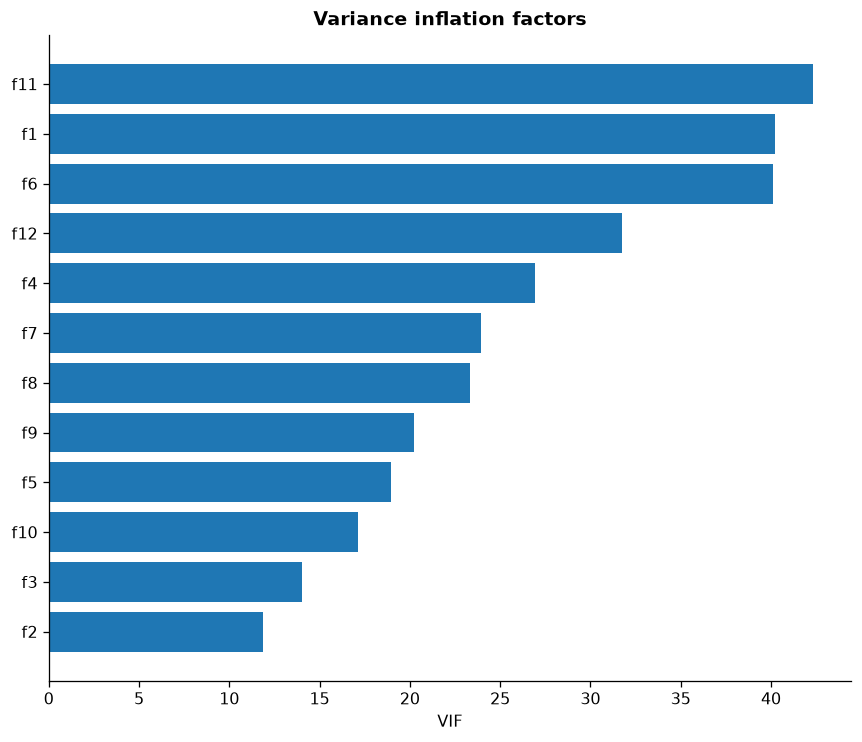

In [4]:
tbl = mv.collinearity.features if hasattr(mv.collinearity,'features') else mv.collinearity.table
if 'vif' in tbl.columns:
    vv=tbl.query('status=="ok"').sort_values('vif',ascending=False).head(12); bar_metric(vv,label='feature',value='vif',title='Variance inflation factors',ylabel='VIF'); plt.show()

## Mahalanobis distance ranking

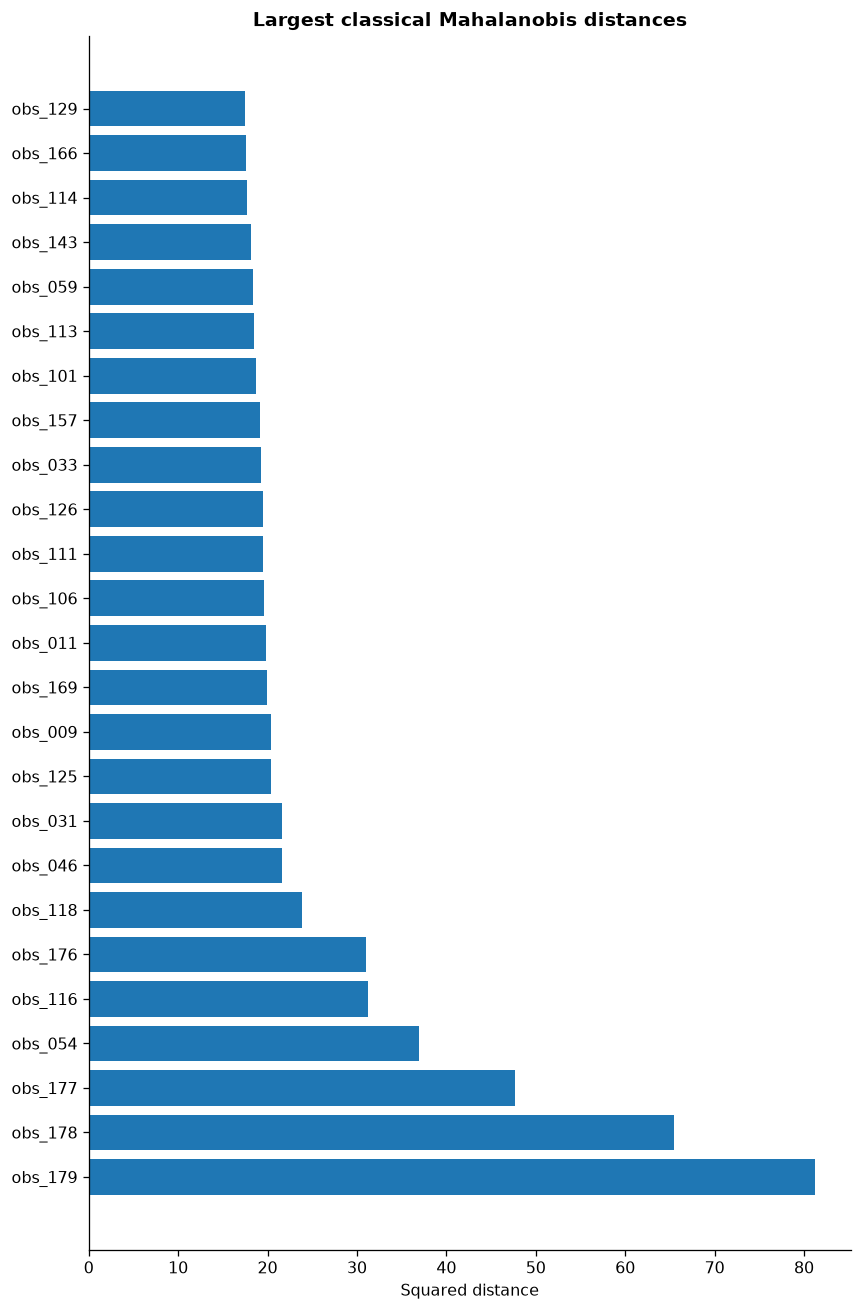

In [5]:
dist=mv.mahalanobis.distances.query('method=="classical" and status=="ok"').sort_values('squared_distance',ascending=False).head(25).copy(); dist['label']=dist.observation_id
bar_metric(dist.sort_values('squared_distance'),label='label',value='squared_distance',title='Largest classical Mahalanobis distances',ylabel='Squared distance'); plt.show()

## Group location in PCA space

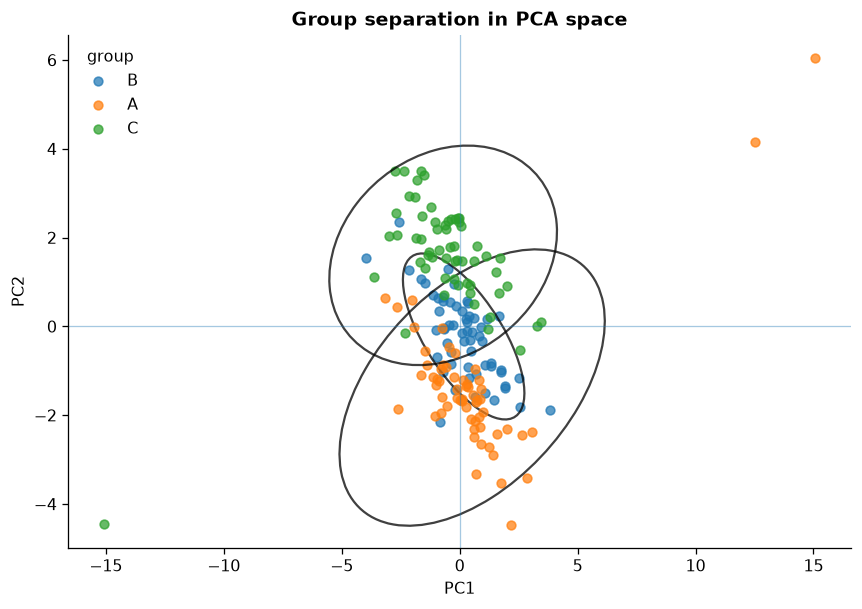

In [6]:
score_plot(pca.scores,frame,x='PC1',y='PC2',group='group',title='Group separation in PCA space',ellipses=True); plt.show()

## PERMANOVA + PERMDISP together

,analysis,factor,statistic,value,df_between,df_within,r_squared,p_value,n_permutations,status,reason
0,permanova,group,pseudo_f,21.132665,2,177,0.192759,0.025,39,ok,None
1,permdisp,group,f_value,0.545723,2,177,NaN,0.500,39,ok,None


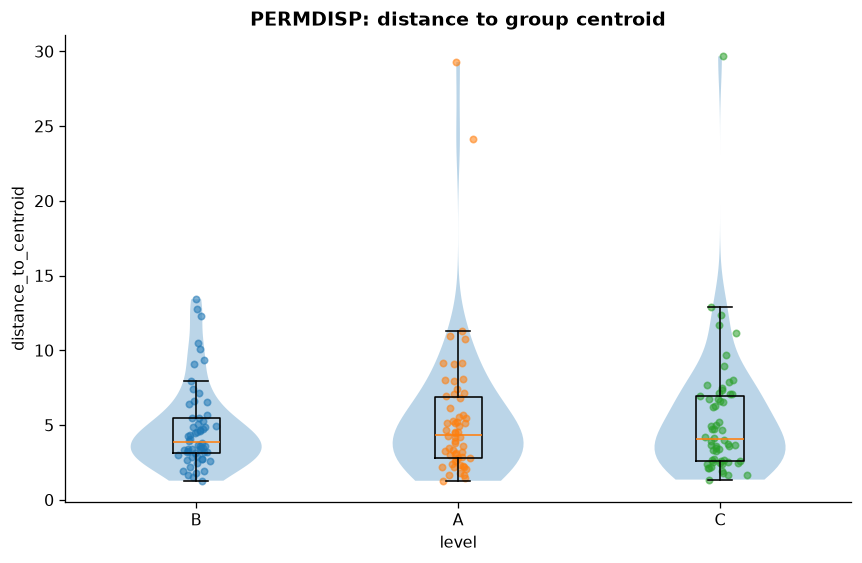

In [7]:
display(perm.summary); d=perm.distances_to_centroid.merge(frame[['id','group']],left_on='observation_id',right_on='id'); group_violin_box_scatter(d,value='distance_to_centroid',group='level',title='PERMDISP: distance to group centroid'); plt.show()

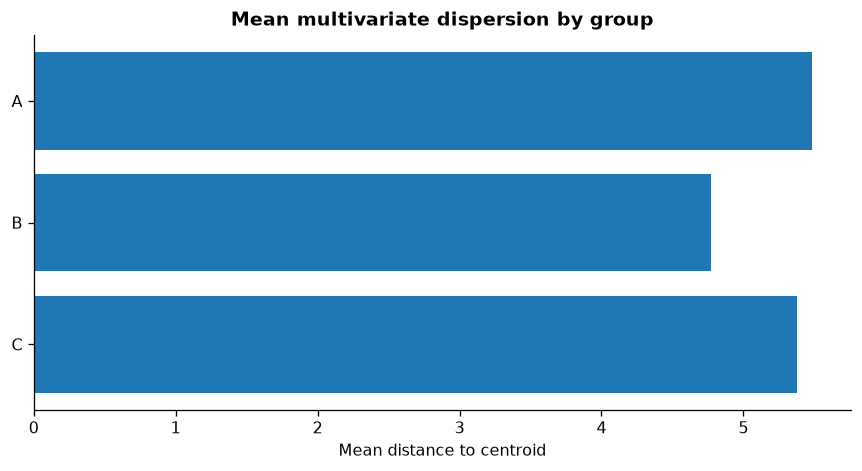

In [8]:
g=perm.groups.copy(); bar_metric(g,label='level',value='mean_distance_to_centroid',title='Mean multivariate dispersion by group',ylabel='Mean distance to centroid'); plt.show()